# Localizing Microscopic Particles


<div style="background-color: #f0f8ff; border: 2px solid #4682b4; padding: 10px;">
<a href="https://colab.research.google.com/github/DeepTrackAI/DeepLearningCrashCourse/blob/main/Ch03_CNN/ec03_B_particle_localization/particle_localization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
<strong>If using Colab/Kaggle:</strong> You need to uncomment the code in the cell below this one.
</div>

In [7]:
!pip install deeplay deeptrack  # Uncomment if using Colab/Kaggle.
!pip install ipympl
get_ipython().kernel.do_shutdown(restart=True)
from google.colab import output
output.enable_custom_widget_manager()
%matplotlib ipympl

This notebook provides you with a complete code example that trains a convolutional neural network with a dense top using annotated and simulated data and then applies it to experimental videos of an optically trapped particle.

<div style="background-color: #f0f8ff; border: 2px solid #4682b4; padding: 10px;">
<strong>Note:</strong> This notebook contains the Code Example 3-B from the book  

**Deep Learning Crash Course**  
Giovanni Volpe, Benjamin Midtvedt, Jesús Pineda, Henrik Klein Moberg, Harshith Bachimanchi, Joana B. Pereira, Carlo Manzo  
No Starch Press, San Francisco (CA), 2026  
ISBN-13: 9781718503922  

[https://nostarch.com/deep-learning-crash-course](https://nostarch.com/deep-learning-crash-course)

You can find the other notebooks on the [Deep Learning Crash Course GitHub page](https://github.com/DeepTrackAI/DeepLearningCrashCourse).
</div>

## Loading the Videos

Download the `particle_dataset`. This folder contains two videos with an optically trapped particle. One video is acquired with very low noise (`low_noise.avi`), while the other with very high noise (`high_noise.avi`).

In [8]:
import os

if not os.path.exists("particle_dataset"):
    os.system("git clone https://github.com/DeepTrackAI/particle_dataset")

Load these videos ...

In [9]:
import cv2
import numpy as np

def load_video(path, frames_to_load, image_size):
    """Load video."""
    video = cv2.VideoCapture(path)

    data = []
    for _ in range(frames_to_load):
        _, frame = video.read()
        frame = cv2.normalize(frame, None, 0, 255, cv2.NORM_MINMAX)
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY) / 255
        frame = cv2.resize(frame, (image_size, image_size))
        data.append(frame)

    return np.array(data)

In [10]:
image_size = 51
video_low_noise = \
    load_video(os.path.join("particle_dataset", "low_noise.avi"),
               frames_to_load=100, image_size=image_size)
video_high_noise = \
    load_video(os.path.join("particle_dataset", "high_noise.avi"),
               frames_to_load=100, image_size=image_size)

... and plot some of the frames.

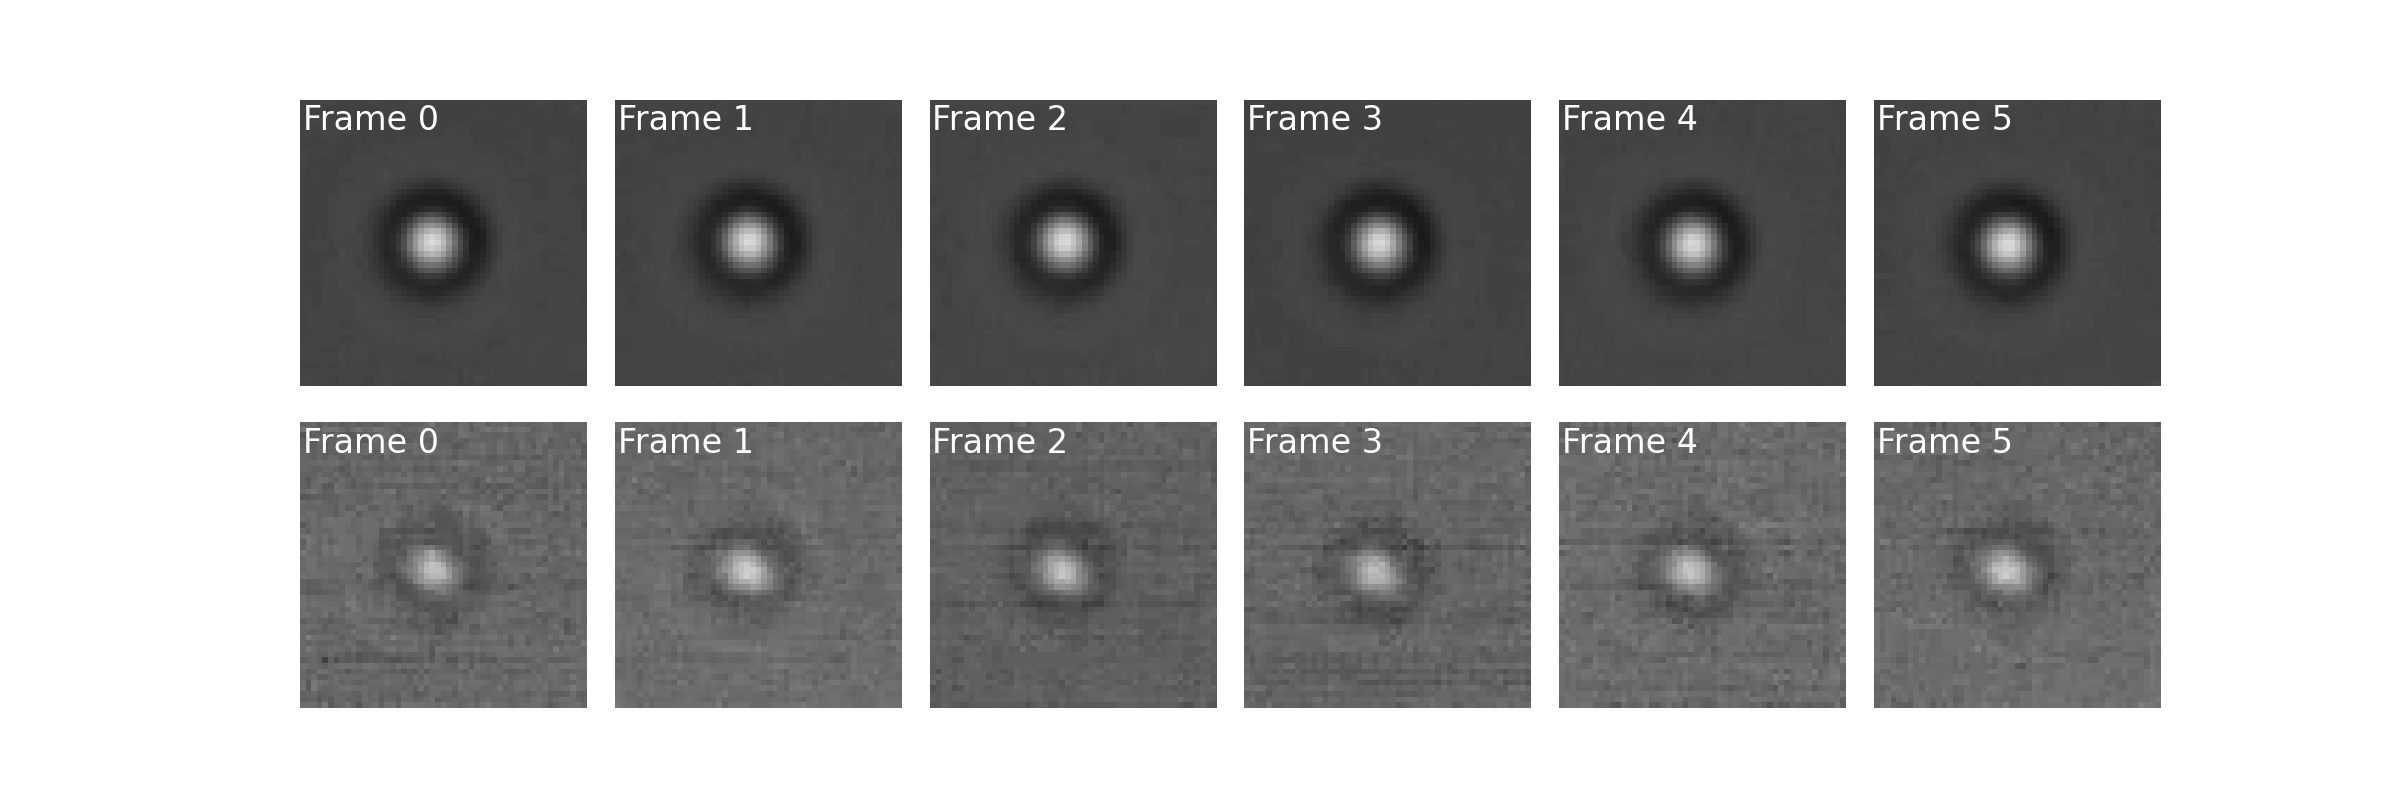

In [11]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 6, figsize=(24, 8))
for i in range(6):
    axs[0, i].imshow(video_low_noise[i], cmap="gray", vmin=0, vmax=1)
    axs[0, i].text(0, 5, f"Frame {i}", color="white", fontsize=24)
    axs[0, i].axis("off")

    axs[1, i].imshow(video_high_noise[i], cmap="gray", vmin=0, vmax=1)
    axs[1, i].text(0, 5, f"Frame {i}", color="white", fontsize=24)
    axs[1, i].axis("off")
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()

## Manually Annotating the Videos

Define a class to be able to interactively select the centroid of particles in some of the video frames ...

In [12]:
from matplotlib.widgets import Cursor

class ManualAnnotation:
    """Graphical interface for manual annotation."""

    def __init__(self, images):
        """Initialize manual annotation."""
        self.images, self.positions, self.i = images, [], 0
        self.fig, self.ax = plt.subplots(1, 1, figsize=(5, 5))
        self.fig.canvas.header_visible = False
        self.fig.canvas.footer_visible = False

    def start(self):
        """Start manual annotation."""
        self.im = self.ax.imshow(self.images[self.i], cmap="gray",
                                 vmin=0, vmax=1)
        self.text = self.ax.text(3, 5,
                                 f"Frame {self.i + 1} of {len(self.images)}",
                                 color="white", fontsize=12)
        self.ax.axis("off")
        self.cursor = Cursor(self.ax, useblit=True, color="red", linewidth=1)
        self.cid = self.fig.canvas.mpl_connect("button_press_event",
                                               self.onclick)
        self.next_image()
        plt.show()

    def next_image(self):
        """Get next image."""
        self.im.set_data(self.images[self.i])
        self.text.set_text(f"Frame {self.i + 1} of {len(self.images)}")
        self.fig.canvas.draw_idle()

    def onclick(self, event):
        """Save position on click."""
        self.positions.append([event.xdata, event.ydata])
        if self.i < len(self.images) - 1:
            self.i += 1
            self.next_image()
        else:
            self.fig.canvas.mpl_disconnect(self.cid)
            plt.close()
            return

... use it to annotate a subset of images ...

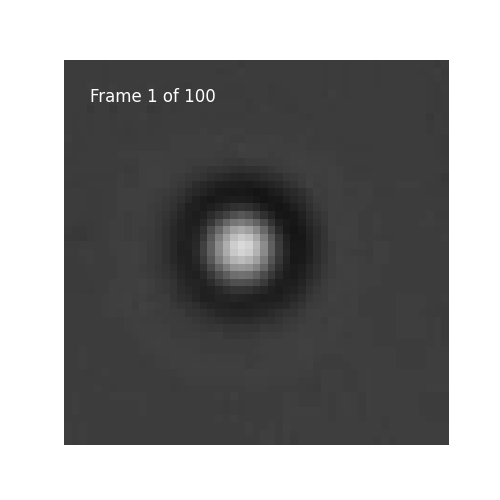

In [13]:

number_of_images_to_annotate = 100

dataset = np.concatenate([video_low_noise, video_high_noise], axis=0)
np.random.shuffle(dataset)
images_to_annotate = np.random.choice(
    np.arange(dataset.shape[0]), number_of_images_to_annotate, replace=False,
)
manual_annotation = ManualAnnotation(dataset[images_to_annotate])
manual_annotation.start()
annotated_images = manual_annotation.images
manual_positions = manual_annotation.positions

%matplotlib inline

... and save the annotated images and relative positions into files.

In [14]:
if not os.path.exists("annotated_images.npy"):
    np.save("annotated_images.npy", np.array(annotated_images))
if not os.path.exists("manual_positions.npy"):
    np.save("manual_positions.npy", np.array(manual_positions))

### Preprocessing the Annotated Data

Define a custom dataset ...

In [15]:
import torch

class AnnotatedDataset(torch.utils.data.Dataset):
    """Manually annotated dataset."""

    def __init__(self, file_images, file_positions):
        """Load annotated images and manual positions."""
        self.images = np.load(file_images)
        self.positions = np.load(file_positions)

    def __len__(self):
        """Return number of images."""
        return self.images.shape[0]

    def __getitem__(self, idx):
        """Get next image and annotated position."""
        im = torch.tensor(self.images[idx, np.newaxis, :, :]).float()
        pos = torch.tensor(self.positions[idx] / im.shape[-1] - 0.5).float()
        return [im, pos]

... create an instance of the dataset with the data you've annotated ...

In [ ]:
ann_dataset = AnnotatedDataset(file_images="annotated_images.npy",
                               file_positions="manual_positions.npy")

... and use it to create the data loaders.

In [ ]:
import deeplay as dl

train_ann_dataset, test_ann_dataset = \
    torch.utils.data.random_split(ann_dataset, [0.8, 0.2])

train_ann_dataloader = dl.DataLoader(train_ann_dataset, batch_size=1)
test_ann_dataloader = dl.DataLoader(test_ann_dataset, batch_size=1)

## Implementing a Convolutional Neural Network for Classification

Sefine a convolutional neural network with a dense top ...

In [ ]:
cnn = dl.Sequential(
    dl.ConvolutionalNeuralNetwork(
        in_channels=1, hidden_channels=[16, 32], out_channels=64,
        pool=torch.nn.MaxPool2d(kernel_size=2), out_activation=torch.nn.ReLU,
    ),
    dl.Layer(torch.nn.MaxPool2d, kernel_size=2),
    dl.Layer(torch.nn.Flatten),
    dl.MultiLayerPerceptron(
        in_features=6 * 6 * 64, hidden_features=[32, 32], out_features=2,
        out_activation=torch.nn.Identity,
    ),
)

print(cnn)

... and compile it for a regression task.

In [ ]:
from torchmetrics import MeanAbsoluteError as MAE

cnn_regressor_template = dl.Regressor(
    model=cnn, loss=torch.nn.MSELoss(), optimizer=dl.Adam(), metrics=[MAE()],
)
cnn_ann_regressor = cnn_regressor_template.create()

print(cnn_ann_regressor)

## Training the Neural Network with Annotated Data

In [ ]:
cnn_ann_trainer = dl.Trainer(max_epochs=50, accelerator="auto")
cnn_ann_trainer.fit(cnn_ann_regressor, train_ann_dataloader)

### Testing the Trained Neural Network

In [ ]:
test_ann_results = cnn_ann_trainer.test(cnn_ann_regressor, test_ann_dataloader)
MAE_ann = test_ann_results[0]["testMeanAbsoluteError_epoch"] * image_size
print(f"Mean pixel error (MAE): {MAE_ann:.3f} pixels")

### Visualizing the Predictions

In [ ]:
indices = np.random.choice(np.arange(len(test_ann_dataset)), 6, replace=False)
images = [test_ann_dataset[index][0] for index in indices]
annotations = [test_ann_dataset[index][1] for index in indices]
predictions = cnn_ann_regressor(torch.stack(images))

fig, axs = plt.subplots(1, 6, figsize=(25, 8))
for ax, im, ann, pred in zip(axs, images, annotations, predictions):
    ax.imshow(im.numpy().squeeze(), cmap="gray")

    ann = ann * image_size + image_size / 2
    ax.scatter(ann[0], ann[1], marker="+", c="g", s=500, linewidth=6,
               label="Annotation")

    pred = pred.detach().numpy() * image_size + image_size / 2
    ax.scatter(pred[0], pred[1], marker="x", c="r", s=500, linewidth=4,
               label="Prediction")

    ax.set_axis_off()
ax.legend(loc=(0.5, 0.8), framealpha=1, fontsize=24)
plt.show()

## Simulating the Training Data

Define the particle ...

In [ ]:
import deeptrack as dt

particle = dt.scatterers.MieSphere(
    position=lambda: np.random.uniform(image_size / 2 - 5,
                                       image_size / 2 + 5, 2),
    z=lambda: np.random.uniform(-1, 1),
    radius=lambda: np.random.uniform(500, 600) * 1e-9,
    refractive_index=lambda: np.random.uniform(1.37, 1.42),
    position_unit="pixel",
)

... specify the optical device to image the particle ...

In [ ]:
brightfield_microscope = dt.optics.Brightfield(
    wavelength=630e-9, NA=0.8, resolution=1e-6, magnification=15,
    refractive_index_medium=1.33, output_region=(0, 0, image_size, image_size),
)

... combine them ...

In [ ]:
imaged_particle = brightfield_microscope(particle)

... and plot them.

In [ ]:
def plot_simulated_particles(image_pipeline):
    """Plot simulated particles."""
    fig, axs = plt.subplots(1, 6, figsize=(25, 8))
    for i, ax in enumerate(axs.flatten()):
        image = image_pipeline.update().resolve()
        ax.imshow(np.squeeze(image), cmap="gray")
        ax.set_xticks([])
        ax.set_yticks([])
    plt.show()

In [ ]:
plot_simulated_particles(imaged_particle)

### Creating Images of Particles with Noise

Adding a Poisson noise source to the simulation pipeline ...

In [ ]:
noise = dt.Poisson(
    min_snr=5, max_snr=20, background=1,
    snr=lambda min_snr, max_snr: np.random.uniform(min_snr, max_snr),
)
noisy_imaged_particle = imaged_particle >> noise

plot_simulated_particles(noisy_imaged_particle)

... and create a pipeline that generates noisy particle images and normalize the pixel values.

In [ ]:
normalization = dt.NormalizeMinMax(lambda: np.random.uniform(0.0, 0.2),
                                   lambda: np.random.uniform(0.8, 1.0))
image_pipeline = noisy_imaged_particle >> normalization

plot_simulated_particles(image_pipeline)

### Getting the Positions from the Simulated Images

Define a pipeline to obtain both the particle image and its centroid position ...

In [ ]:
pipeline = image_pipeline & particle.position

... and plot the particle positions on top of the particle images.

In [ ]:
def plot_simulated_particles_with_positions(pipeline):
    """Plot simulated particles with positions."""
    fig, axs = plt.subplots(1, 6, figsize=(25, 8))
    for i, ax in enumerate(axs.flatten()):
        image, position = pipeline.update().resolve()
        ax.imshow(np.squeeze(image), cmap="gray")
        ax.scatter(position[1], position[0], s=500, facecolors="none",
                   edgecolors="g", linewidth=6)
        ax.set_xticks([])
        ax.set_yticks([])
    plt.show()

In [ ]:
plot_simulated_particles_with_positions(pipeline)

### Preprocessing the Simulated Data

Create a database to work with the simulated particle images ...

In [ ]:
class SimulatedDataset(torch.utils.data.Dataset):
    """Dataset with simulated particles."""

    def __init__(self, pipeline, data_size):
        """Initialize simulated dataset."""
        images, positions = [], []
        for _ in range(data_size):
            image, position = pipeline.update().resolve()
            images.append(image), positions.append(position[[1, 0]])
        self.images, self.positions = np.array(images), np.array(positions)

    def __len__(self):
        """Return number of images."""
        return self.images.shape[0]

    def __getitem__(self, idx):
        """Get next simulated image and position."""
        im = torch.tensor(self.images[idx]).float().permute(2, 0, 1)
        pos = torch.tensor(self.positions[idx] / im.shape[-1] - 0.5).float()
        return [im, pos]

... and create the training and test data loaders.

In [ ]:
train_sim_dataloader = dl.DataLoader(
    SimulatedDataset(pipeline=pipeline, data_size=10_000), batch_size=32,
)
test_sim_dataloader = dl.DataLoader(
    SimulatedDataset(pipeline=pipeline, data_size=100), batch_size=32,
)

## Training the Neural Network with Simulated Data

In [ ]:
cnn_sim_regressor = cnn_regressor_template.create()
cnn_sim_trainer = dl.Trainer(max_epochs=50, accelerator="auto")
cnn_sim_trainer.fit(cnn_sim_regressor, train_sim_dataloader)

### Testing the Trained Neural Network

In [ ]:
test_sim_results = cnn_sim_trainer.test(cnn_sim_regressor, test_sim_dataloader)
MAE_sim = test_sim_results[0]["testMeanAbsoluteError_epoch"] * image_size
print(f"Mean pixel error (MAE): {MAE_sim:.3f} pixels")

### Plotting the Predictions Versus the Ground Truth

In [ ]:
preds, gts = [], []
for image, position in iter(test_sim_dataloader):
    preds.append(cnn_sim_regressor(image))
    gts.append(position)
preds = torch.cat(preds, dim=0).detach().numpy()
gts = torch.cat(gts, dim=0).numpy()

fig, axs = plt.subplots(1, 2)
for i, ax, coordinate in zip([0, 1], axs, ["x", "y"]):
    gt, pred = gts[:][:, i], preds[:][:, i]
    ax.scatter(gt, pred, alpha=0.2)
    ax.plot([np.min(gt), np.max(gt)], [np.min(pred), np.max(pred)], c="k")
    ax.set_title(f"{coordinate}-coordinates")
    ax.set_xlabel("Prediction")
    ax.set_ylabel("Ground truth")
    ax.set_aspect("equal")
    ax.set_xlim([-0.07, 0.07])
    ax.set_ylim([-0.07, 0.07])
    ax.label_outer()
plt.show()

### Comparing with the Annotated Data

In [ ]:
test_ann_results_with_cnn_sim = \
    cnn_sim_trainer.test(cnn_sim_regressor, test_ann_dataloader)
MAE_ann_with_cnn_sim = (test_ann_results_with_cnn_sim[0]
                        ["testMeanAbsoluteError_epoch"] * image_size)
print(f"Mean pixel error (MAE): {MAE_ann_with_cnn_sim:.3f} pixels")

In [ ]:
indices = np.random.choice(np.arange(len(test_ann_dataset)), 6, replace=False)
images = [test_ann_dataset[index][0] for index in indices]
annotations = [test_ann_dataset[index][1] for index in indices]
predictions = cnn_sim_regressor(torch.stack(images))

fig, axs = plt.subplots(1, 6, figsize=(25, 8))
for ax, im, ann, pred in zip(axs, images, annotations, predictions):
    ax.imshow(im.numpy().squeeze(), cmap="gray")

    ann = ann * image_size + image_size / 2
    ax.scatter(ann[0], ann[1], marker="+", c="g", s=500, linewidth=6,
               label="Annotation")

    pred = pred.detach().numpy() * image_size + image_size / 2
    ax.scatter(pred[0], pred[1], marker="x", c="r", s=500, linewidth=4,
               label="Prediction")

    ax.set_axis_off()
ax.legend(loc=(0.5, 0.8), framealpha=1, fontsize=24)
plt.show()